In [5]:
import geopandas as gpd
import pandas as pd

In [2]:
j1v_c2 =gpd.read_file("../data/raw/2023-24_Hotspots/DL_FIRE_J1V-C2_666396/fire_archive_J1V-C2_666396.shp")
sv_c2 = gpd.read_file("../data/raw/2023-24_Hotspots/DL_FIRE_SV-C2_666398/fire_archive_SV-C2_666398.shp")

In [3]:
j1v_c2.head()

,LATITUDE,LONGITUDE,BRIGHTNESS,SCAN,TRACK,ACQ_DATE,ACQ_TIME,SATELLITE,INSTRUMENT,CONFIDENCE,VERSION,BRIGHT_T31,FRP,DAYNIGHT,TYPE,geometry
0,45.02904,-79.68185,335.56,0.65,0.73,2023-10-01,1654,N20,VIIRS,n,2,285.14,5.60,D,0,POINT (-79.68185 45.02904)
1,45.02495,-79.67978,328.84,0.65,0.73,2023-10-01,1654,N20,VIIRS,n,2,285.03,7.52,D,0,POINT (-79.67978 45.02495)
2,51.00452,-78.61643,352.09,0.37,0.58,2023-10-01,1656,N20,VIIRS,n,2,300.03,15.12,D,0,POINT (-78.61643 51.00452)
3,51.00306,-78.62123,367.00,0.37,0.58,2023-10-01,1656,N20,VIIRS,h,2,295.55,15.12,D,0,POINT (-78.62123 51.00306)
4,51.00598,-78.61163,367.00,0.37,0.58,2023-10-01,1656,N20,VIIRS,h,2,293.90,20.33,D,0,POINT (-78.61163 51.00598)


In [6]:
# merge and filter CONFIDENCE to n or h
hotspots = gpd.GeoDataFrame(pd.concat([j1v_c2, sv_c2], ignore_index=True))
hotspots = hotspots[hotspots["CONFIDENCE"].isin(["n", "h"])]
hotspots.head()

,LATITUDE,LONGITUDE,BRIGHTNESS,SCAN,TRACK,ACQ_DATE,ACQ_TIME,SATELLITE,INSTRUMENT,CONFIDENCE,VERSION,BRIGHT_T31,FRP,DAYNIGHT,TYPE,geometry
0,45.02904,-79.68185,335.56,0.65,0.73,2023-10-01,1654,N20,VIIRS,n,2,285.14,5.60,D,0,POINT (-79.68185 45.02904)
1,45.02495,-79.67978,328.84,0.65,0.73,2023-10-01,1654,N20,VIIRS,n,2,285.03,7.52,D,0,POINT (-79.67978 45.02495)
2,51.00452,-78.61643,352.09,0.37,0.58,2023-10-01,1656,N20,VIIRS,n,2,300.03,15.12,D,0,POINT (-78.61643 51.00452)
3,51.00306,-78.62123,367.00,0.37,0.58,2023-10-01,1656,N20,VIIRS,h,2,295.55,15.12,D,0,POINT (-78.62123 51.00306)
4,51.00598,-78.61163,367.00,0.37,0.58,2023-10-01,1656,N20,VIIRS,h,2,293.90,20.33,D,0,POINT (-78.61163 51.00598)


<Axes: >

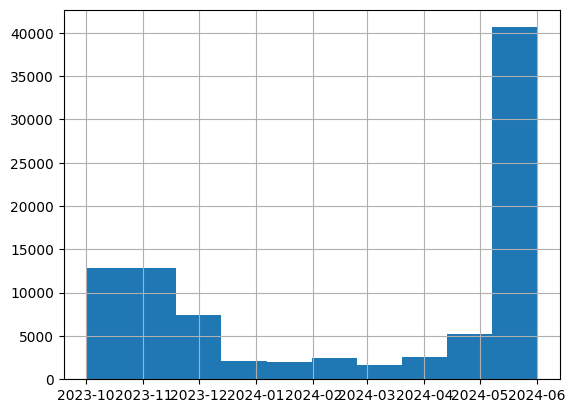

In [ ]:
# plot the histogram of ACQ_DATE
hotspots["ACQ_DATE"] = pd.to_datetime(hotspots["ACQ_DATE"])
hotspots["ACQ_DATE"].hist()


In [8]:
# get month, year columns
hotspots["month"] = hotspots["ACQ_DATE"].dt.month
hotspots["year"] = hotspots["ACQ_DATE"].dt.year

<Axes: >

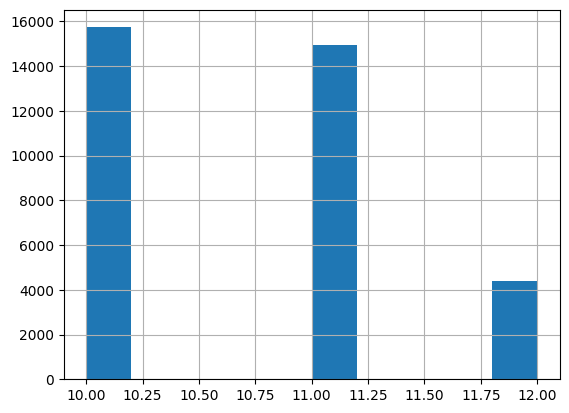

In [9]:
#Plot histogram of month and year for 2023
hotspots_2023 = hotspots[hotspots["year"] == 2023]
hotspots_2023["month"].hist()

In [12]:
#get zone_wgs coords
zone_wgs = gpd.read_file("../data/processed_study_zones/study_zones_wgs.geojson")
# get zone_wgs bounds
zone_wgs_bounds = zone_wgs.total_bounds
print(zone_wgs_bounds)

[-128.92587704   56.08975917 -120.00127162   60.0047828 ]
